In [1]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

In [2]:
# load data
X =np.load('data/f6/updated_inputs.npy')
y=np.load('data/f6/updated_outputs.npy')

In [3]:
# Normalization
y_mean_val = np.mean(y)
y_std_val  = np.std(y)
y_norm    = (y - y_mean_val) / y_std_val if y_std_val > 0 else y

In [4]:
# compute mean distance between data
distances = pdist(X, metric='euclidean')

In [5]:
# Grid for evaluation
from scipy.stats import qmc

dim=5
n_grid = 5000 
sampler = qmc.LatinHypercube(d=dim, seed=42)
sample = sampler.random(n=n_grid)

# compute lower and upper bounds
l_bounds = X.min(axis=0)  
u_bounds = X.max(axis=0)  
x_grid_d = qmc.scale(sample, l_bounds, u_bounds)

In [6]:
# The current best
best_f = np.max(y_norm)
best_idx = np.argmax(y_norm)
print(f"Mejor observación actual: X = {X[best_idx]}, y_norm = {best_f:.4f}")

Mejor observación actual: X = [0.39935  0.384569 0.48774  0.792305 0.238639], y_norm = 2.1347


In [7]:
# EI
xi = 0.1
def expected_improvement(mean, std, best_f, xi):
    Z  = (mean - best_f - xi) / (std + 1e-9)
    ei = (mean - best_f - xi) * norm.cdf(Z) + std * norm.pdf(Z)
    ei[std <= 0.0] = 0.0
    return ei

In [8]:
# find optimal lengthscale
noise_assumption = 1.e-4
Alpha=[]
Mean=[]
STD=[]
for alpha in np.linspace(0.1, 3, 30):
    rbf_lengthscale  = alpha*distances.mean()#alpha times mean distance

    kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
    model  = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)
    model.fit(X, y_norm)

    # GP prediction ---
    post_mean, post_std = model.predict(x_grid_d, return_std=True)

    ei_values = expected_improvement(post_mean, post_std, best_f, xi)
    # The next point
    idx_next  = np.argmax(ei_values)# simple grid
    x_next    = x_grid_d[idx_next]
    Alpha.append(alpha)
    Mean.append(post_mean[idx_next])
    STD.append(post_std[idx_next])

Alpha for max mean= 1.8


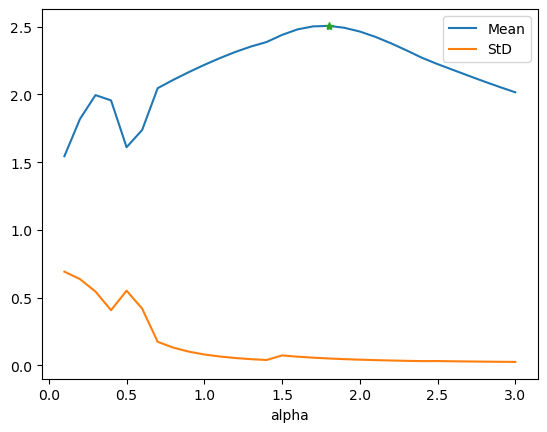

In [9]:
# identify best alpha
id_max = np.argmax(Mean)
plt.plot(Alpha,Mean, label='Mean')
plt.plot(Alpha,STD, label='StD')
plt.plot(Alpha[id_max], Mean[id_max], marker='*')
plt.xlabel('alpha')
plt.legend()
print('Alpha for max mean=',Alpha[id_max])

In [10]:
# re-compute maximum
alpha=Alpha[id_max]
rbf_lengthscale  = alpha*distances.mean()#max mean distance
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model  = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)
model.fit(X, y_norm)
# GP prediction ---
post_mean, post_std = model.predict(x_grid_d, return_std=True)
ei_values = expected_improvement(post_mean, post_std, best_f, xi)
# The next point
idx_next  = np.argmax(ei_values)# simple grid
x_next    = x_grid_d[idx_next]
std_next = post_std[idx_next]
y_next = post_mean[idx_next]#Next Point

print(f"Proppsed query from (EI): x1={x_next[0]:.8f}, x2={x_next[1]:.8f}, x3={x_next[2]:.8f}, x4={x_next[3]:.8f}, x5={x_next[4]:.8f}")
print('mean next (y_norm)=',post_mean[idx_next])
print('mean next (y)=',post_mean[idx_next]*y_std_val+y_mean_val)
print('std next=',post_std[idx_next])

#query from EI
x_next_ei = x_next
y_next_ei = y_next

Proppsed query from (EI): x1=0.48899449, x2=0.14245127, x3=0.76016654, x4=0.95960006, x5=0.12187692
mean next (y_norm)= 2.5060164358779957
mean next (y)= -0.18144779568736502
std next= 0.0496722144545392


In [11]:
# UCB acquisition: find best k
K=[]
Mean=[]
STD=[]
for k in np.linspace(0.1, 3, 30):
    #UCB (maximize)
    # The next point
    acquisition = post_mean + k * post_std
    idx_next = np.argmax(acquisition)
    x_next = x_grid_d[idx_next]
    K.append(k)
    Mean.append(post_mean[idx_next])
    STD.append(post_std[idx_next])

K for max mean= 0.1


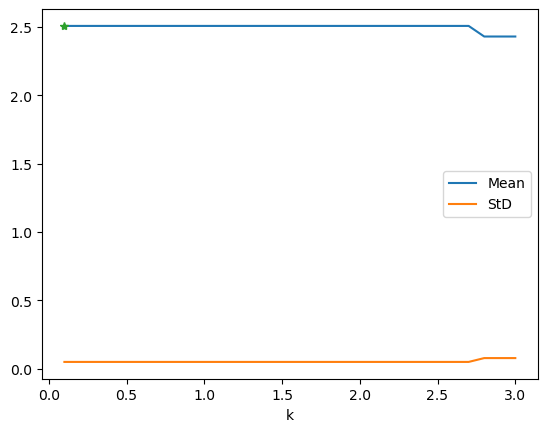

In [12]:
# plot k optimization
id_max = np.argmax(Mean)
plt.plot(K,Mean, label='Mean')
plt.plot(K,STD, label='StD')
plt.plot(K[id_max], Mean[id_max], marker='*')
plt.xlabel('k')
plt.legend()

print('K for max mean=',K[id_max])

In [15]:
# re-compute maximum
acquisition = post_mean + K[id_max] * post_std
idx_next = np.argmax(acquisition)
x_next = x_grid_d[idx_next]
std_next = post_std[idx_next]
y_next = post_mean[idx_next]
    
print(f"Suggested query (UCB): x1={x_next[0]:.8f}, x2={x_next[1]:.8f}, x3={x_next[2]:.8f}, x4={x_next[3]:.8f}, x5={x_next[4]:.8f}")
print('mean next (normalized)=',post_mean[idx_next])
print('mean next=',post_mean[idx_next]*y_std_val+y_mean_val)
print('std next=',post_std[idx_next])

#query from UCB
x_next_ucb = x_next
y_next_ucb = y_next

Suggested query (UCB): x1=0.48899449, x2=0.14245127, x3=0.76016654, x4=0.95960006, x5=0.12187692
mean next (normalized)= 2.5060164358779957
mean next= -0.18144779568736502
std next= 0.0496722144545392


In [16]:
# RSM Method
import pandas as pd
from statsmodels.formula.api import ols

In [17]:
# create dataframe
data = np.column_stack((X,y_norm))
df = pd.DataFrame(data, columns=['x1', 'x2', 'x3', 'x4', 'x5', 'y_norm'])
# fit regression model
model = ols(formula='y_norm ~ x1 + x2 + x3 + x4 + x5 + I(x1**2) + I(x2**2) + I(x3**2) + I(x4**2) + I(x5**2)', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 y_norm   R-squared:                       0.970
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     35.73
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           6.08e-07
Time:                        12:13:13   Log-Likelihood:                 7.4046
No. Observations:                  22   AIC:                             7.191
Df Residuals:                      11   BIC:                             19.19
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.2109      0.393     -5.619      0.0

In [18]:
# Optimization (Gradient Descent - Simplified)
from scipy.optimize import minimize

def objective(Xin):
    x1, x2, x3, x4, x5 = Xin
    return -model.predict(pd.DataFrame({'x1': [x1], 'x2': [x2], 'x3': [x3], 'x4': [x4], 'x5': [x5]}))[0]

initial_guess = X[best_idx] #starting from best current value
print('X best=',X[best_idx])
result = minimize(objective, initial_guess, bounds=[(0, 1.), (0, 1.), (0, 1.), (0, 1.), (0, 1.)], method='L-BFGS-B')
optimal = result.x
print('optimal=',optimal)
print('objective (y_norm)=',-objective(optimal))
print('objective (y)=',-objective(optimal)*y_std_val+y_mean_val)

#query from RSM
x_next_rsm = optimal
y_next_rsm = -objective(optimal)

X best= [0.39935  0.384569 0.48774  0.792305 0.238639]
optimal= [0.43808018 0.40550814 0.66767628 0.74395489 0.        ]
objective (y_norm)= 2.1135718879194405
objective (y)= -0.3759225520593954


In [19]:
# Choose the best option between EI, UCB and RSM
if y_next_ei >= y_next_ucb and y_next_ei >= y_next_rsm:
    x_next_out = x_next_ei
elif y_next_ucb > y_next_ei and y_next_ucb > y_next_rsm:
    x_next_out = x_next_ucb
else:
    x_next_out = x_next_rsm

# Write output file
import os
folder = 'results'
filename = 'output_F6.txt'
file_path = os.path.join(folder, filename)
with open(file_path, 'w', encoding='utf-8') as f:
    f.write(f"{x_next_out[0]:.6f} {x_next_out[1]:.6f} {x_next_out[2]:.6f} {x_next_out[3]:.6f} {x_next_out[4]:.6f}\n")